In [1]:
import pandas
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split, cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, make_scorer, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn import datasets
from sklearn.preprocessing import LabelBinarizer
from sklearn.neural_network import MLPClassifier
import time
import pickle

In [2]:
# Load dataset
url = "https://goo.gl/NXoJfR"
dataset = pandas.read_csv(url, header=None)

# Descriptive statistics
# shape
print(dataset.shape)

(208, 61)


In [3]:
# types
pandas.set_option('display.max_rows', 500)
print(dataset.dtypes)

0     float64
1     float64
2     float64
3     float64
4     float64
5     float64
6     float64
7     float64
8     float64
9     float64
10    float64
11    float64
12    float64
13    float64
14    float64
15    float64
16    float64
17    float64
18    float64
19    float64
20    float64
21    float64
22    float64
23    float64
24    float64
25    float64
26    float64
27    float64
28    float64
29    float64
30    float64
31    float64
32    float64
33    float64
34    float64
35    float64
36    float64
37    float64
38    float64
39    float64
40    float64
41    float64
42    float64
43    float64
44    float64
45    float64
46    float64
47    float64
48    float64
49    float64
50    float64
51    float64
52    float64
53    float64
54    float64
55    float64
56    float64
57    float64
58    float64
59    float64
60     object
dtype: object


In [4]:
# head
pandas.set_option('display.width', 100)
print(dataset.head(20))

        0       1       2       3       4       5       6       7       8       9   ...      51  \
0   0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109  0.2111  ...  0.0027   
1   0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337  0.2872  ...  0.0084   
2   0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598  0.6194  ...  0.0232   
3   0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598  0.1264  ...  0.0121   
4   0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564  0.4459  ...  0.0031   
5   0.0286  0.0453  0.0277  0.0174  0.0384  0.0990  0.1201  0.1833  0.2105  0.3039  ...  0.0045   
6   0.0317  0.0956  0.1321  0.1408  0.1674  0.1710  0.0731  0.1401  0.2083  0.3513  ...  0.0201   
7   0.0519  0.0548  0.0842  0.0319  0.1158  0.0922  0.1027  0.0613  0.1465  0.2838  ...  0.0081   
8   0.0223  0.0375  0.0484  0.0475  0.0647  0.0591  0.0753  0.0098  0.0684  0.1487  ...  0.0145   
9   0.0164

In [5]:
# descriptions, change precision to 3 places
pandas.set_option('display.precision', 3)
print(dataset.describe())

            0          1        2        3        4        5        6        7        8        9   \
count  208.000  2.080e+02  208.000  208.000  208.000  208.000  208.000  208.000  208.000  208.000   
mean     0.029  3.844e-02    0.044    0.054    0.075    0.105    0.122    0.135    0.178    0.208   
std      0.023  3.296e-02    0.038    0.047    0.056    0.059    0.062    0.085    0.118    0.134   
min      0.002  6.000e-04    0.002    0.006    0.007    0.010    0.003    0.005    0.007    0.011   
25%      0.013  1.645e-02    0.019    0.024    0.038    0.067    0.081    0.080    0.097    0.111   
50%      0.023  3.080e-02    0.034    0.044    0.062    0.092    0.107    0.112    0.152    0.182   
75%      0.036  4.795e-02    0.058    0.065    0.100    0.134    0.154    0.170    0.233    0.269   
max      0.137  2.339e-01    0.306    0.426    0.401    0.382    0.373    0.459    0.683    0.711   

       ...       50         51         52       53         54         55         56       

In [6]:
# class distribution
print(dataset.groupby(60).size())

60
M    111
R     97
dtype: int64


In [ ]:
# histograms
dataset.hist(sharex=False, sharey=False, xlabelsize=1, ylabelsize=1)
plt.show()

In [ ]:
# density
dataset.plot(kind='density', subplots=True, layout=(8,8), sharex=False, legend=False,
fontsize=1)
plt.show()

In [7]:
# Split-out validation dataset
array = dataset.values
X = array[:,0:60].astype(float)
Y = array[:,60]
validation_size = 0.20
seed = 7
X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y,
test_size=validation_size, random_state=seed)

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.signal import find_peaks
import scipy
import matplotlib.pyplot as plt

def classify_col(col):
    s = skew(col, bias=False)
    # reglas simples de sesgo
    if s > 1: lbl = 'muy sesgada derecha'
    elif s > 0.5: lbl = 'moderada derecha'
    elif s < -1: lbl = 'muy sesgada izquierda'
    elif s < -0.5: lbl = 'moderada izquierda'
    else: lbl = 'aprox simétrica'
    # multimodal check via KDE peaks
    vals = np.linspace(col.min(), col.max(), 200)
    kde = scipy.stats.gaussian_kde(col)
    dens = kde(vals)
    peaks, _ = find_peaks(dens, height=np.max(dens)*0.15)  # umbral relativo
    if len(peaks) >= 2:
        lbl += ' + multimodal'
    return s, kurtosis(col, fisher=True), lbl

results = []
# X is a numpy array, iterate through column indices
for c_idx in range(X.shape[1]):
    # Select the column data for the classify_col function
    col_data = X[:, c_idx]
    s, k, lbl = classify_col(col_data)
    results.append({'col':c_idx,'skew':s,'kurtosis':k,'label':lbl})

resdf = pd.DataFrame(results).set_index('col')
print(resdf['label'].value_counts())
print(resdf.sort_values('skew').head())  # ver las más sesgadas

In [ ]:
# box and whisker plots
dataset.plot(kind='box', subplots=True, layout=(8,8), sharex=False, sharey=False,
fontsize=1)
plt.show()

In [ ]:
# correlation matrix
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(
    dataset.iloc[:,0:60].corr(),
    vmin=-1,
    vmax=1,
    interpolation='none',
    cmap='RdBu_r'
)
fig.colorbar(cax)
plt.show()

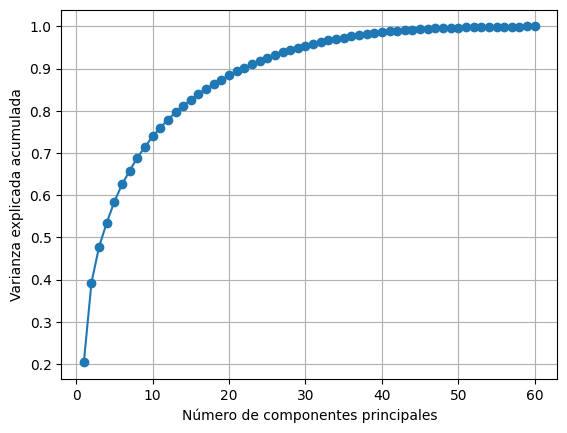

Componentes para explicar 90% de la varianza: 22


In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = dataset.iloc[:, :60].values
# opcional: escalar si no está escalado (StandardScaler)
Xs = StandardScaler().fit_transform(X)

pca = PCA(n_components=60)
pca.fit(Xs)
explained = np.cumsum(pca.explained_variance_ratio_)

import matplotlib.pyplot as plt
plt.figure()
plt.plot(np.arange(1,61), explained, marker='o')
plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza explicada acumulada')
plt.grid(True)
plt.show()

# ver cuantos componentes para 90%
n90 = np.searchsorted(explained, 0.90) + 1
print('Componentes para explicar 90% de la varianza:', n90)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

R = dataset.iloc[:, :60].corr().values  # 60x60
lags = np.arange(0, 60)
mean_corr_by_lag = np.array([R[np.arange(60 - l), np.arange(l, 60)].mean() for l in lags])

plt.figure()
plt.plot(lags, mean_corr_by_lag, marker='o')
plt.xlabel('Lag (separación en índices de banda)')
plt.ylabel('Correlación media para ese lag')
plt.grid(True)
plt.show()

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

# Convertir correlación a distancia (1 - corr)
dist = 1 - R
# Asegurar simetría y valores en [0,2]
dist = (dist + dist.T) / 2
np.fill_diagonal(dist, 0.0)

# Usar linkage con distancia condensada
Z = linkage(squareform(dist), method='average')

plt.figure(figsize=(8,3))
dendrogram(Z, labels=np.arange(60))
plt.title('Dendrograma de bandas (agrupación por correlación)')
plt.xlabel('Índice de banda')
plt.show()

# Elegir, por ejemplo, 8 clusters
clusters = fcluster(Z, t=8, criterion='maxclust')
print('Clusters por banda:', clusters)

In [9]:
# Encode string labels 'R' and 'M' to numerical (0 or 1)
# LabelBinarizer is suitable for this, as MLPClassifier expects numerical targets.
lb = LabelBinarizer()
Y_train_encoded = lb.fit_transform(Y_train).ravel() # .ravel() converts [[0], [1]] to [0, 1]
# Y_validation will also need to be encoded later if used directly with the model
Y_validation_encoded = lb.transform(Y_validation).ravel()


In [10]:
#Modelo red neuronal

random_state = 2

RNA = Pipeline([
    ('power', PowerTransformer(method='yeo-johnson', standardize=True)),
    ('mlp', MLPClassifier(hidden_layer_sizes=(1000,500,250), activation='relu',
                          solver='adam', alpha=1e-4,
                          learning_rate_init=1e-3,
                          early_stopping=True,
                          max_iter=10000,
                          random_state=random_state,
                          batch_size ='auto'))
])

In [11]:
tic = time.perf_counter()
RNA.fit(X_train, Y_train_encoded)
toc = time.perf_counter()
print("Entrenamiento completo")
print("Tiempo de procesador para el entrenamiento (seg):")
print(toc - tic)

Entrenamiento completo
Tiempo de procesador para el entrenamiento (seg):
0.3866298000793904


In [12]:
# predecir los valores de X_test
predicted = RNA.predict(X_validation)

# para finalizar se calcula el error
acc = accuracy_score(Y_validation_encoded, predicted)
error = 1 - acc
print("Accuracy:")
print(acc)
print("Error en el conjunto de prueba:")
print(error)

# el modelo entrenado se salva en disco
filename = 'modelRNA.sav'
pickle.dump(RNA, open(filename, 'wb'))

Accuracy:
0.8571428571428571
Error en el conjunto de prueba:
0.1428571428571429


In [13]:
# Test options and evaluation metric
num_folds = 10
num_instances = len(X_train)
seed = 7
scoring = 'accuracy'

In [ ]:
# Spot-Check Algorithms
models = []
models.append(('LR', LogisticRegression()))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))

In [ ]:
results = []
names = []
for name, model in models:
    kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
    cv_results = cross_val_score(model, X_train, Y_train_encoded, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

In [ ]:
# Compare Algorithms
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

In [ ]:
# Standardize the dataset
pipelines = []
pipelines.append(('ScaledLR', Pipeline([('Scaler', StandardScaler()),('LR',
LogisticRegression())])))
pipelines.append(('ScaledLDA', Pipeline([('Scaler', StandardScaler()),('LDA',
LinearDiscriminantAnalysis())])))
pipelines.append(('ScaledKNN', Pipeline([('Scaler', StandardScaler()),('KNN',
KNeighborsClassifier())])))
pipelines.append(('ScaledCART', Pipeline([('Scaler', StandardScaler()),('CART',
DecisionTreeClassifier())])))
pipelines.append(('ScaledNB', Pipeline([('Scaler', StandardScaler()),('NB',
GaussianNB())])))
pipelines.append(('ScaledSVM', Pipeline([('Scaler', StandardScaler()),('SVM', SVC())])))
results = []
names = []
for name, model in pipelines:
  kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
  cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
  results.append(cv_results)
  names.append(name)
  msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
  print(msg)

In [ ]:
# Compare Algorithms
fig = plt.figure()
fig.suptitle('Scaled Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

In [ ]:
scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train)
neighbors = [1,3,5,7,9,11,13,15,17,19,21]
param_grid = dict(n_neighbors=neighbors)
model = KNeighborsClassifier()
kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=kfold)
grid_result = grid.fit(rescaledX, Y_train)
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
for mean_score, std_score, params in zip(grid_result.cv_results_['mean_test_score'], grid_result.cv_results_['std_test_score'], grid_result.cv_results_['params']):
  print("%f (%f) with: %r" % (mean_score, std_score, params))

In [14]:
# Standardize the dataset
pipelines = []
pipelines.append(('LR', Pipeline([('Power+Scaler', PowerTransformer(method='yeo-johnson', standardize=True)),('LR', LogisticRegression())])))
pipelines.append(('LDA', Pipeline([('Scaler', StandardScaler()),('LDA', LinearDiscriminantAnalysis())])))
pipelines.append(('KNN', Pipeline([('Power+Scaler', PowerTransformer(method='yeo-johnson', standardize=True)),('KNN', KNeighborsClassifier())])))
pipelines.append(('CART', Pipeline([('CART', DecisionTreeClassifier())])))
pipelines.append(('NB', Pipeline([('Power', PowerTransformer(method='yeo-johnson', standardize=False)),('NB', GaussianNB())])))
pipelines.append(('SVM', Pipeline([('Scaler', StandardScaler()),('SVM', SVC())])))
pipelines.append(('RNA', RNA))

results = []
names = []
for name, model in pipelines:
  kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
  cv_results = cross_val_score(model, X_train, Y_train_encoded, cv=kfold, scoring=scoring)
  results.append(cv_results)
  names.append(name)
  msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
  print(msg)

LR: 0.791176 (0.091259)
LDA: 0.778676 (0.093570)
KNN: 0.813603 (0.074116)
CART: 0.728676 (0.081793)
NB: 0.712868 (0.116961)
SVM: 0.826103 (0.081814)
RNA: 0.790074 (0.051404)


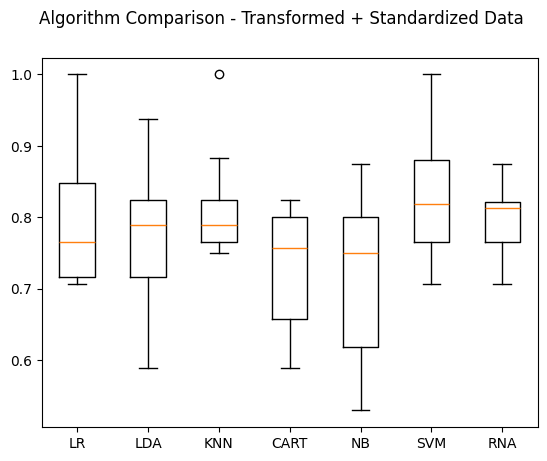

In [15]:
# Compare Algorithms
fig = plt.figure()
fig.suptitle('Algorithm Comparison - Transformed + Standardized Data')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

In [ ]:
# Tune scaled SVM
scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train)
c_values = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0, 1.3, 1.5, 1.7, 2.0]
kernel_values = ['linear', 'poly', 'rbf', 'sigmoid']
param_grid = dict(C=c_values, kernel=kernel_values)
model = SVC()
kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=kfold)
grid_result = grid.fit(rescaledX, Y_train)
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
for mean_score, std_score, params in zip(grid_result.cv_results_['mean_test_score'], grid_result.cv_results_['std_test_score'], grid_result.cv_results_['params']):
  print("%f (%f) with: %r" % (mean_score, std_score, params))

In [ ]:
# ensembles
ensembles = []
ensembles.append(('AB', AdaBoostClassifier()))
ensembles.append(('GBM', GradientBoostingClassifier()))
ensembles.append(('RF', RandomForestClassifier()))
ensembles.append(('ET', ExtraTreesClassifier()))
results = []
names = []
for name, model in ensembles:
  kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
  cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
  results.append(cv_results)
  names.append(name)
  msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
  print(msg)

In [ ]:
# Compare Algorithms
fig = plt.figure()
fig.suptitle('Ensemble Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

In [ ]:
# prepare the model
scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train)
model = SVC(C=1.5)
model.fit(rescaledX, Y_train)
# estimate accuracy on validation dataset
rescaledValidationX = scaler.transform(X_validation)
predictions = model.predict(rescaledValidationX)
print(accuracy_score(Y_validation, predictions))
print(confusion_matrix(Y_validation, predictions))
print(classification_report(Y_validation, predictions))